# 🛒 Amazon Reviews - Sentiment Analysis

This notebook performs **sentiment analysis** on a dataset of Amazon customer reviews. It classifies each review as **Positive**, **Negative**, or **Neutral** based on the tone of the text, then visualizes the overall sentiment breakdown.

**Dataset:** `Amazon_Reviews.csv` (place this file in the same folder as this notebook)

**Tools used:**
- `pandas` — to load and work with the review data
- `textblob` — a natural language processing library that scores text sentiment
- `matplotlib` — to visualize the results

**Setup:** `textblob` isn't part of standard Python, so install it first (run once in a notebook cell, then restart the kernel):
```python
!pip install textblob
!python -m textblob.download_corpora
```


## Step 1: Load the Dataset

We read the CSV file into a pandas DataFrame. A few extra options are used because real-world review data is often messy:
- `engine="python"` — a more flexible CSV parser that handles irregular rows better
- `encoding="latin1"` — many review exports use this encoding instead of UTF-8, and using the wrong one causes errors on special characters
- `on_bad_lines="skip"` — skips any rows that are malformed instead of crashing


In [1]:
import pandas as pd
from textblob import TextBlob

# Load dataset
df = pd.read_csv(
    "Amazon_Reviews.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)


## Step 2: Define a Sentiment Scoring Function

`TextBlob` analyzes a piece of text and returns a **polarity score** between -1 (very negative) and +1 (very positive), with 0 meaning neutral.

Our function converts that score into a simple label:
- Score **> 0** → `"Positive"`
- Score **< 0** → `"Negative"`
- Score **= 0** → `"Neutral"`

Wrapping the input in `str(text)` guards against blank/missing reviews, which would otherwise cause an error when TextBlob tries to read them.


In [1]:
# Sentiment Function
def get_sentiment(text):

    score = TextBlob(str(text)).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"


## Step 3: Apply Sentiment Analysis to Every Review

We run `get_sentiment()` on every row of the `Review Text` column with `.apply()`, storing the result in a new `Sentiment` column. Then we print the first 5 rows to check that it worked, and print a count of how many reviews fall into each sentiment category.

**Output:** out of roughly 21,200 reviews, **10,616 came back Positive**, **8,344 Negative**, and **2,254 Neutral**.


In [1]:
# Apply Sentiment Analysis
df["Sentiment"] = df["Review Text"].apply(get_sentiment)

# Display Results
print(df[["Review Text", "Sentiment"]].head())

print("\nSentiment Counts:")
print(df["Sentiment"].value_counts())


                                         Review Text Sentiment
0  I registered on the website, tried to order a ...  Negative
1  Had multiple orders one turned up and driver h...  Negative
2  I informed these reprobates that I WOULD NOT B...  Negative
3  I have bought from Amazon before and no proble...  Negative
4  If I could give a lower rate I would! I cancel...   Neutral

Sentiment Counts:
Sentiment
Positive    10616
Negative     8344
Neutral      2254
Name: count, dtype: int64


## Step 4: Bar Chart of Sentiment Counts

A simple bar chart shows how many reviews fall into each sentiment category, making it easy to see at a glance whether customers are mostly happy, unhappy, or neutral.

**Result:** Positive reviews are the largest group (10,616), followed by Negative (8,344), with Neutral reviews being the smallest category (2,254).


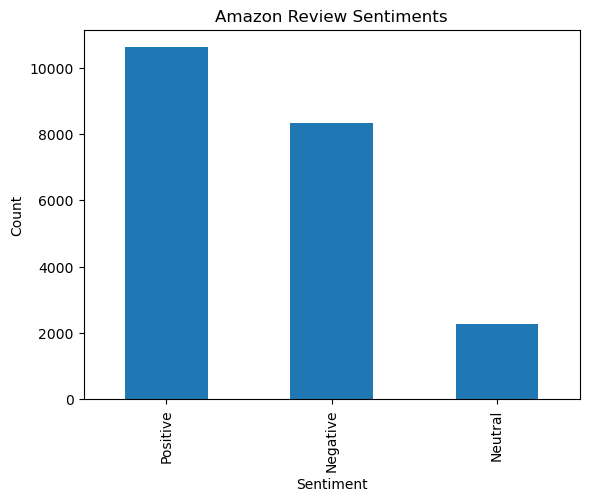

In [1]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Amazon Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


## Step 5: Pie Chart of Sentiment Distribution

The pie chart shows the same information as a percentage breakdown, which is often easier to interpret at a glance than raw counts.

**Result:** About **50% of reviews are Positive**, **39.3% are Negative**, and **10.6% are Neutral** — meaning positive and negative sentiment are nearly balanced, with genuinely neutral reviews being rare.


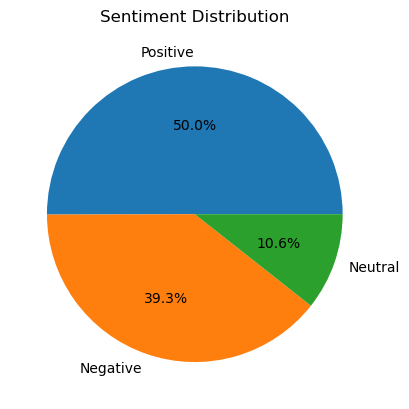

In [1]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()


## Summary

In this notebook we:
1. Loaded a messy real-world Amazon reviews CSV, handling encoding and bad-line issues
2. Built a simple polarity-based sentiment classifier using TextBlob
3. Applied it across every review and counted the results
4. Visualized the sentiment breakdown with a bar chart and a pie chart

**Key takeaway:** Roughly half of reviewers left positive feedback, but a substantial 39% left negative reviews — worth digging into further (e.g. filtering negative reviews to find common complaints) if this were a real business analysis.

### Possible next steps
- Extract the most common words/phrases in negative reviews
- Compare sentiment against the numeric `Rating` column
- Track sentiment trends over time using `Review Date`
